# Introduction to Using Neural Networks for Images: Convolutional Neural Networks

Author: Dr. Julie Butler

Date Created: June 30, 2026

Last Modified: June 30, 2026

Created for the _University of Mount Union Data Science Summer Camp_, July 31 and August 1, 2026.

## Introduction

In our first session, we built a [neural network](https://en.wikipedia.org/wiki/Neural_network_(machine_learning)) that could predict whether a passenger on the Titanic survived. That network worked with a small number of **features** (like passenger class and fare), and every input was connected to every neuron in the next layer. This works great for a handful of numbers, but what happens when we want a computer to look at a *picture*?

In this session, we will learn about a special kind of neural network called a [**Convolutional Neural Network**](https://en.wikipedia.org/wiki/Convolutional_neural_network), or **CNN** for short. CNNs are the technology behind facial recognition, self-driving cars, medical image analysis, and the photo filters on your phone. 

### Why Can't We Just Use a Regular Neural Network?

Let's think about what an image actually *is* to a computer. An image is just a grid of numbers, where each number represents the brightness of one **pixel** (at least for grayscale images). A small grayscale image that is 28 pixels wide and 28 pixels tall contains 28 × 28 = **784 numbers**.

That might not sound too bad. But a regular neural network (like our Titanic model) connects *every* input to *every* neuron. If we feed in a normal phone photo, which might be 200 × 200 pixels in full color, that's 200 × 200 × 3 = **120,000 numbers** as input (x3 because you need three numbers to represent color). Connecting all of those to even a single layer of neurons would create *billions* of connections to train. That is far too slow, requires a huge amount of data, and the network would easily become [overfit](https://en.wikipedia.org/wiki/Overfitting).

There is a second, sneakier problem. A regular network treats pixel #1 and pixel #500 as completely unrelated, even if they sit right next to each other. But in an image, **nearby pixels are related** — they form edges, shapes, and objects. A regular network throws away this important clue. We need a network that is designed specifically for images. That is exactly what a CNN is. 

You don't identify a cat by memorizing the exact brightness of one specific pixel. Instead, your brain notices **features**: pointy ears, whiskers, fur, round eyes. And importantly, a cat is still a cat whether it is in the top-left corner of a photo or the bottom-right. CNNs are built to copy both of these ideas:
1. **Look for features** (edges, shapes, textures) instead of memorizing exact pixels.
2. **Find those features anywhere** in the image, no matter where they appear.

The base of a CNN is something called a [**filter**](https://en.wikipedia.org/wiki/Kernel_(image_processing)) (also called a **kernel**). A filter is a small window — often just 3 pixels by 3 pixels — that slides across the image looking for **one specific pattern**, such as a vertical edge, a curve, or a patch of a certain color. The result is a new image called a [**feature map**](https://en.wikipedia.org/wiki/Convolutional_neural_network#Feature_maps) that shows *where* in the original picture that pattern was found.

The clever part is that the **same filter is reused at every position**. This is what makes CNNs efficient — there are far fewer numbers to learn — and it is what lets the network find a feature no matter where it appears (the "cat in any corner" idea). The action of sliding a filter across an image is called a **convolution**, which is where the "Convolutional" in CNN comes from.

## A Demonstration
This website, [CNN Explainer](https://poloclub.github.io/cnn-explainer/), helps to demonstrate how a CNN can take an image and pull out meaningful information. Note that it does take quite a long time to load. Sometimes pressing refresh will make it load a bit faster.

Note that there is one thing in most CNN implementations that not shown in this CNN Explainer. After the convolutional layers and pooling layers, before the final decision is made, there are usually one or more "normal" (feedforward) neural network layers. The idea is that these layers will take the feature map refined by the convolutional and pooling layers and further refine the data and find patterns before the final determination is made.

## Important Terms
* [Convolution]():
* [Filter]():
* [Convolutional Layer]():
* [Max Pooling Layer]():
* [Kernel]():
* [Kernel Size]():
* [Feature Map]():

## A Python Implementation

In [1]:
#############
## IMPORTS ##
#############
# All of the importants and some code are in the CNN_Wrapper.py file. This is just a wrapper to make it 
# easier to use the CNN class. If you want to see the code for the CNN class, you can look in the 
# CNN_Wrapper.py file, but don't worry about understanding it for now. Just know that you can use the CNN 
# class to create a convolutional neural network and train it on your data.
from CNN_Wrapper import *

In [2]:
###################
## LOAD THE DATA ##
###################
# get_mnist_data is a function that loads the MNIST dataset and returns the training and test data as 
# PyTorch DataLoader objects. The batch_size parameter specifies how many samples per batch to load.
# You can change the batch_size to a different value if you want.

# Note that this data is already preprocessed and normalized, so you don't need to do any additional preprocessing. 
# The images are 28x28 grayscale images of clothing, and the labels are the corresponding clothing categories.
train_data, test_data = get_mnist_data(batch_size=64)

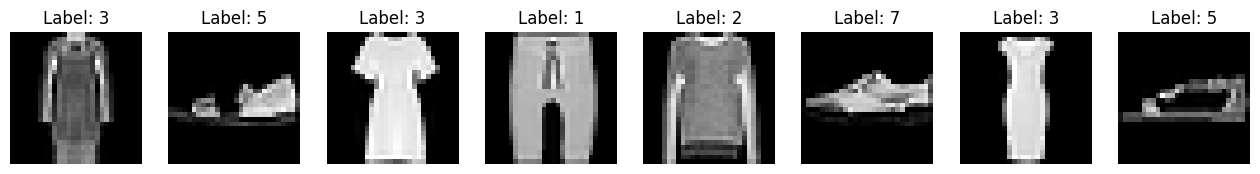

In [3]:
########################
## DATA VISUALIZATION ##
########################
# Visualize some of the training data to get a sense of what the images look like.
visualize_data(train_data, num_images=8)

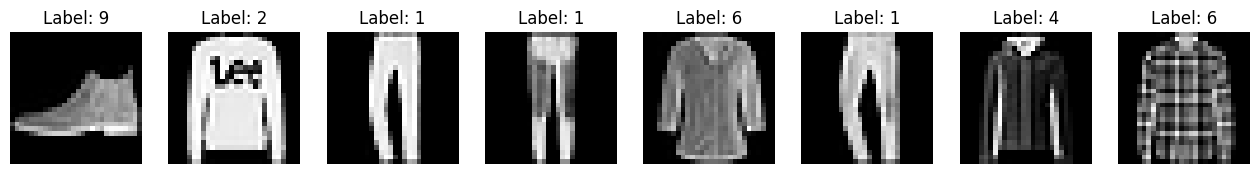

In [7]:
visualize_data(test_data, num_images=8)

In [ ]:
####################
## DEFINE THE CNN ##
####################
# build_cnn is a function that creates a convolutional neural network (CNN) model, loss function, 
# and optimizer based on the specified parameters. You can change the parameters to create different CNN architectures.
model, criterion, optimizer, device = build_cnn(
                                        conv_channels=(32, 64),
                                        kernel_size=3,
                                        pool_size=2,
                                        hidden_neurons=128,
                                        dropout=0.25,
                                        activation="relu",
                                        learning_rate=1e-3,
                            )

### Explaination of the Hyperparameters

* `conv_channels = (32, 64)` — This sets up the filters (the "magnifying glasses" that scan for patterns). The network has two convolutional layers: the first uses 32 different filters, and the second uses 64. The first layer hunts for simple things like edges; the second uses more filters because it's combining those edges into more complex shapes, and there are more possible shapes than there are edges.
* `kernel_size = 3` — This is the size of each filter window: 3×3 pixels. So each filter looks at a little 9-pixel patch of the image at a time as it slides across. Small windows like this are standard because they catch local details like an edge or corner.
* `pool_size = 2` — This controls the "zooming out" (pooling) step. A value of 2 means the network shrinks the image by looking at 2×2 blocks and keeping just the most important value from each, cutting the width and height in half. This makes the network faster and less fussy about exactly where a feature sits.
* `hidden_neurons = 128` — After the filters do their work, a regular neural network (like the Titanic one) makes the final decision. This is the size of that decision-making layer: 128 neurons. More neurons give it more "room to think," but too many can slow things down or cause memorizing.
* `dropout = 0.25` — This is a trick to prevent overfitting (memorizing the training data instead of actually learning). During training, it randomly switches off 25% of the neurons each round. By forcing the network to work even when parts are missing, it learns sturdier, more general patterns instead of leaning on any single neuron. Think of it like a sports team practicing with random players sitting out, so everyone gets good and the team doesn't depend on one star.
* `activation = "relu"` — This is the activation function, the rule inside each neuron that decides what signal to pass on. ReLU is the most common one: it keeps positive numbers as-is and turns negatives into zero. Its real job is adding the "bend" that lets the network learn complex, curvy patterns instead of just straight-line relationships. Other options for the activation function are "tanh" or "sigmoid".
* `learning_rate=1e-3` — This is how big a step the network takes each time it adjusts itself. 1e-3 is scientific notation for 0.001, a small step. Too big and the network overshoots and never settles; too small and it learns painfully slowly. This value is a common, reliable middle ground.

In [9]:

###################
## TRAIN THE CNN ##
###################
epochs = 5
for epoch in range(1, epochs + 1):
    loss = train(model, train_data, optimizer, criterion, device)
    print("Epoch:", epoch, "Training Loss:", loss)
    

Epoch: 1 Training Loss: 0.18547126327753066
Epoch: 2 Training Loss: 0.16911987564563752
Epoch: 3 Training Loss: 0.1540836270372073
Epoch: 4 Training Loss: 0.1435327594657739
Epoch: 5 Training Loss: 0.13065946830709776


In [8]:
acc = evaluate(model, test_data, device)
print("Test accuracy:", acc*100, "%")


Test accuracy: 90.28 %


## Challenge

Perform _hyperparameter tuning_ by changing the batch size (from the `get_mnist_data` function) and all of the hyperparameters defined in the `build_cnn` function. You can also change the `epochs` defined above the training loop. Try as many different combinations as possible in order to get the highest test accuraccy possible!

## Conclusion and Future Directions

## Resources for Further Investigation